This file analyses the compounded return, as well as the risk-adjusted return of 4 assets
from different industries and compares them to the performance of S&P 500 over the past 5 years

Assets used: Apple, JP Morgan, Coca-Cola, Exxon Mobil


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt

end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL","JPM","KO","XOM", "^GSPC"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.round(3)

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2021-05-19,121.542,141.987,46.672,49.075,4115.68
2021-05-20,124.096,141.740,47.086,48.959,4159.12
2021-05-21,122.263,143.353,47.060,49.025,4155.86
2021-05-24,123.891,144.128,47.215,49.600,4197.05
2021-05-25,123.696,142.639,47.206,48.476,4188.13
...,...,...,...,...,...
2026-05-11,292.680,300.000,78.660,148.671,7412.84
2026-05-12,294.800,304.880,80.030,149.615,7400.96
2026-05-13,298.870,300.250,80.260,150.548,7444.25


In [115]:
returns = df.pct_change().dropna()
returns.round(4)

Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2021-05-20,0.0210,-0.0017,0.0089,-0.0024,0.0106
2021-05-21,-0.0148,0.0114,-0.0005,0.0014,-0.0008
2021-05-24,0.0133,0.0054,0.0033,0.0117,0.0099
2021-05-25,-0.0016,-0.0103,-0.0002,-0.0226,-0.0021
2021-05-26,-0.0004,-0.0001,0.0044,0.0117,0.0019
...,...,...,...,...,...
2026-05-11,-0.0013,-0.0070,0.0031,0.0353,0.0019
2026-05-12,0.0072,0.0163,0.0174,0.0063,-0.0016
2026-05-13,0.0138,-0.0152,0.0029,0.0062,0.0058


In [116]:
avg_returns = returns.mean()
annual_returns = (1+avg_returns)**252 - 1
annual_returns.round(3)

Ticker
AAPL     0.245
JPM      0.196
KO       0.131
XOM      0.311
^GSPC    0.142
dtype: float64

Text(0, 0.5, 'Return (%)')

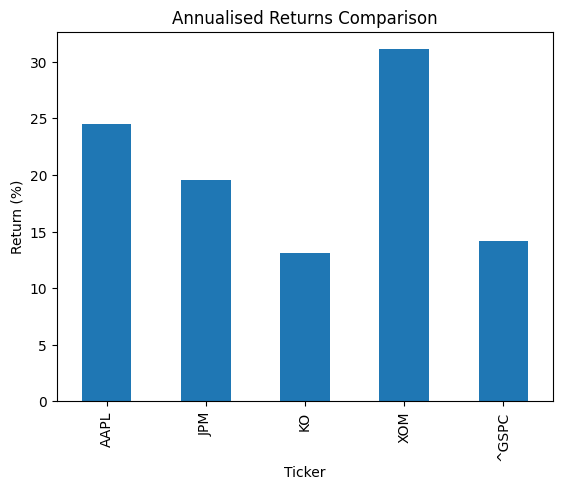

In [117]:
(annual_returns*100).plot(kind='bar')
plt.title('Annualised Returns Comparison')
plt.ylabel('Return (%)')

In [118]:
annual_volatility = returns.std()*252**0.5
annual_volatility.round(3)

Ticker
AAPL     0.275
JPM      0.244
KO       0.160
XOM      0.267
^GSPC    0.169
dtype: float64

Text(0, 0.5, 'Volatility')

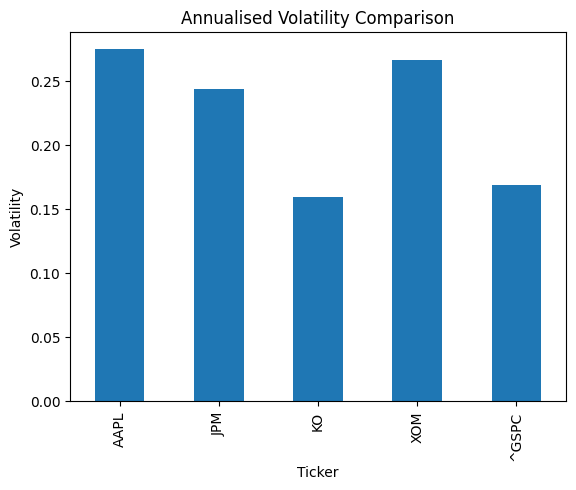

In [119]:
annual_volatility.plot(kind='bar')
plt.title('Annualised Volatility Comparison')
plt.ylabel('Volatility')

In [120]:
sharpe_ratio = annual_returns/annual_volatility
sharpe_ratio.round(3)

Ticker
AAPL     0.893
JPM      0.802
KO       0.821
XOM      1.166
^GSPC    0.838
dtype: float64

Text(0.5, 1.0, 'Sharpe Ratio Comparison')

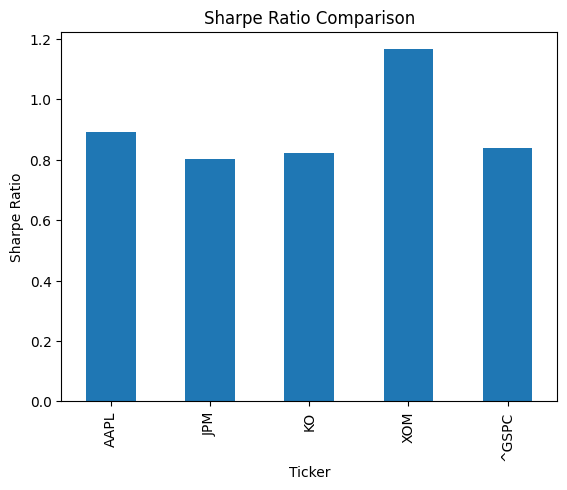

In [121]:
sharpe_ratio.plot(kind='bar')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Ticker')
plt.title('Sharpe Ratio Comparison')

In [122]:
compound = (1+returns).cumprod() - 1
final_compounded_return = compound.tail(1)
final_compounded_return.round(3)

Ticker,AAPL,JPM,KO,XOM,^GSPC
Date,,,,,
2026-05-15,1.47,1.097,0.732,2.218,0.8


Text(0, 0.5, 'Asset Growth')

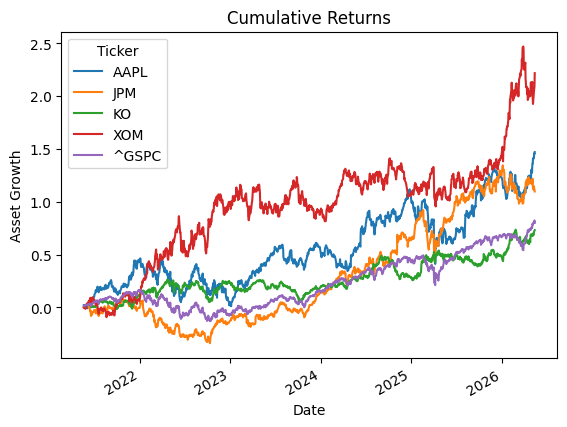

In [123]:
compound.plot()
plt.title('Cumulative Returns')
plt.ylabel('Asset Growth')

Exxon Mobil shows best compounded return over 5 years

Exxon Mobil shows best risk-adjusted return and highest Sharpe Ratio

Apple Was the most volatile asset with the most annualised volatility

Only Coca-Cola performed worse than the benchmark S&P 500 in terms of returns

S&P 500 had a better risk-adjusted return than both JP Morgan and Coca-Cola